<a href="https://colab.research.google.com/github/Taniice/Analisis-Visitantes-a-Sitios-Arqueologicos/blob/main/Analisis_Visitas_a_Sitios_Arqueologicos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Analisis Visitantes a sitios arqueologicos
#INTEGRANTES
# Tania Pamela Apaza Vilca
#Jose Jhonatan Quispe Cartagena

In [72]:
# 1. IMPORTAR LIBRERÍAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [73]:
# 2. CONECTAR GOOGLE DRIVE
from google.colab import drive
drive.mount('/content/drive')

# 3. CARGAR BASE DE DATOS
ruta = "/content/drive/MyDrive/base de datos sitios.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [74]:
#Obtener el dataframe
df = pd.read_csv(ruta, encoding='latin1', sep=';')

In [75]:
#Consultar las filas
print("Primeras filas:")
print(df.head())

#Consultar la información del dataframe
print("\nInformación:")
print(df.info())

# Mostrar resumen estadístico del DataFrame (media, mínimo, máximo, etc.)
print("\nDescripción estadística:")
print(df.describe())

Primeras filas:
   FECHA_CORTE  ANIO  COD_DPTO  NOM_DPTO                            NOM_MUSEO  \
0     20260505  2007         1  Amazonas  Zona Arqueológica Monumental Kuélap   
1     20260505  2007         1  Amazonas  Zona Arqueológica Monumental Kuélap   
2     20260505  2007         1  Amazonas  Zona Arqueológica Monumental Kuélap   
3     20260505  2007         1  Amazonas  Zona Arqueológica Monumental Kuélap   
4     20260505  2007         1  Amazonas  Zona Arqueológica Monumental Kuélap   

   COD_MES  NOM_MES  COD_TIPO     NOM_TIPO  ADU_BOLESPPAGANTES  ...  \
0        1    Enero         0   Nacionales                   0  ...   
1        1    Enero         1  Extranjeros                   0  ...   
2        2  Febrero         0   Nacionales                   0  ...   
3        2  Febrero         1  Extranjeros                   0  ...   
4        3    Marzo         0   Nacionales                   0  ...   

   EST_BOLESPNOPAGANTES  NIN_BOLESPNOPAGANTES  MIL_BOLESPNOPAGANTES  \

In [76]:
# 5. LIMPIEZA DE DATOS
# Convertir la columna TOTAL a numérico
df['TOTAL'] = pd.to_numeric(df['TOTAL'], errors='coerce')

# Eliminar valores nulos en TOTAL
df = df.dropna(subset=['TOTAL'])

In [77]:
#cambiamos nombres técnicos a nombres claros y entendibles
#Cambio de JOSE
df = df.rename(columns={
    'FECHA_CORTE': 'fecha',
    'ANIO': 'anio',
    'COD_DPTO': 'cod_departamento',
    'NOM_DPTO': 'departamento',
    'NOM_MUSEO': 'sitio',
    'COD_MES': 'cod_mes',
    'NOM_MES': 'mes',
    'COD_TIPO': 'cod_tipo_visitante',
    'NOM_TIPO': 'tipo_visitante',
    'TOTAL': 'total_visitantes',
    'TOTAL_PAGANTES': 'visitantes_pagantes',
    'TOTAL_NOPAGANTES': 'visitantes_no_pagantes',
    'TIPO_cat_cod': 'categoria'
})

In [78]:
#reorganizamos y filtramos el dataset para dejarlo limpio y listo para el análisis
#cambio de JOSE

df = df[[
    'fecha', 'anio', 'mes',
    'departamento', 'sitio',
    'tipo_visitante',
    'visitantes_pagantes',
    'visitantes_no_pagantes',
    'total_visitantes'
]]

In [79]:
# Convertir fecha de texto o número a fecha real(datetime)
df['fecha'] = pd.to_datetime(df['fecha'], format='%Y%m%d')

# Ordenar datos primero año y luego mes
df = df.sort_values(by=['anio', 'mes'])

# Limpiar textos(normalizar datos)
df['tipo_visitante'] = df['tipo_visitante'].replace({
    'Nacionales': 'Nacional',
    'Extranjeros': 'Extranjero'
})

In [80]:
#reorganizamos los números de la fila del DataFrame
#CAMBIO DE JOSE
df = df.reset_index(drop=True)#evitamos que el indice viejo se convierta en una columna extra
df = df[df['total_visitantes'] >= 0]# evitamos que el índice viejo se convierta en una columna extra

In [81]:
# Convertir columnas a tipo numerico (int o float)
#CAMBIO DE JOSE
cols_numericas = ['total_visitantes', 'visitantes_pagantes', 'visitantes_no_pagantes']

for col in cols_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Eliminar filas con datos clave nulos
df = df.dropna(subset=cols_numericas)#eliminamos columnas con datos nulos

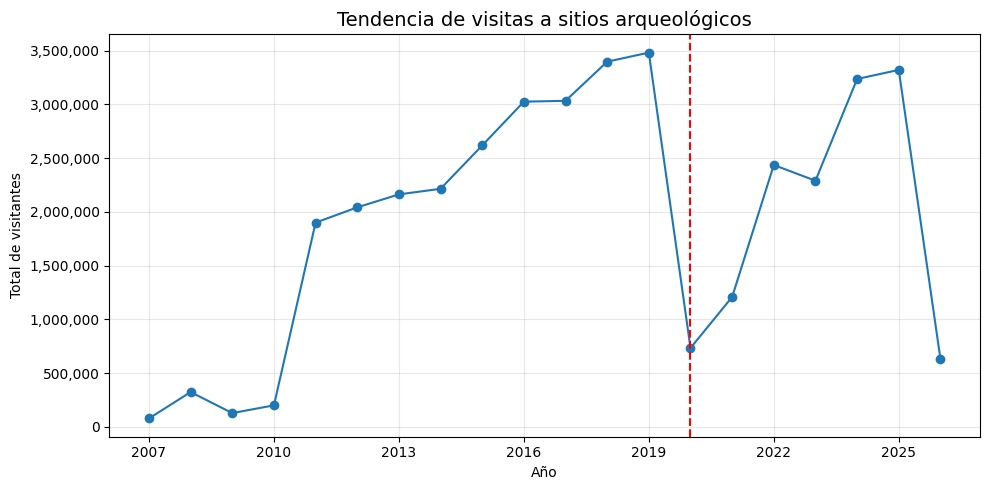

In [82]:
# 6. ANÁLISIS 1: VISITAS POR AÑO
# Asegurar que 'anio' sea entero
df['anio'] = df['anio'].astype(int)

# Agrupar por año(sumanos todos los visitantes por cada año)
visitas_anio = df.groupby('anio')['total_visitantes'].sum()

# Gráfico
plt.figure(figsize=(10,5))
visitas_anio.plot(marker='o') #ponemos puntos en cada año

# Línea vertical en pandemia
#plt.axvline(x=2020, linestyle='--')
plt.axvline(x=2020, color='red', linestyle='--', label='COVID-19 (2020)')

plt.title("Tendencia de visitas a sitios arqueológicos", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Total de visitantes")
# para no mostrar con decimales
import matplotlib.ticker as ticker

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
# hasta aqui
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

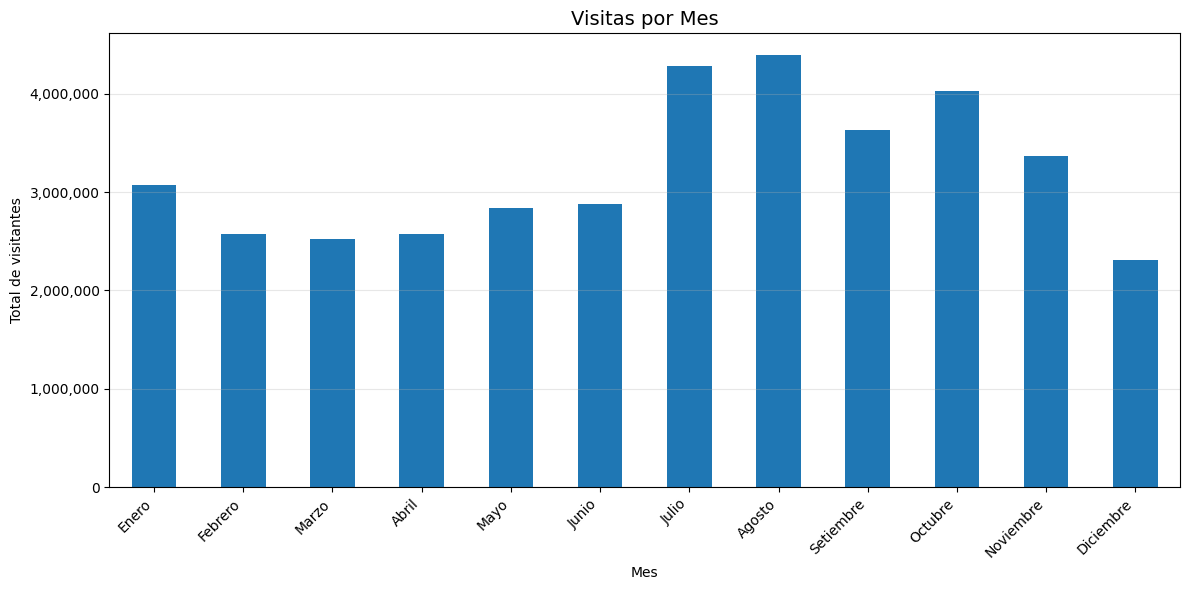

In [83]:
# 7. ANÁLISIS 2: VISITAS POR MES
visitas_mes = df.groupby('mes')['total_visitantes'].sum() #Sumamos los visitantes de cada mes sin importar el año
#deninimos el orden correcto de meses
orden_meses = [
    'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
    'Julio', 'Agosto', 'Setiembre', 'Octubre', 'Noviembre', 'Diciembre'
]

visitas_mes = visitas_mes.reindex(orden_meses) #reordenamos los meses

plt.figure(figsize=(12,6))
visitas_mes.plot(kind='bar')

plt.title("Visitas por Mes", fontsize=14)
plt.xlabel("Mes")
plt.ylabel("Total de visitantes")
#para no mostrar con decimales
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

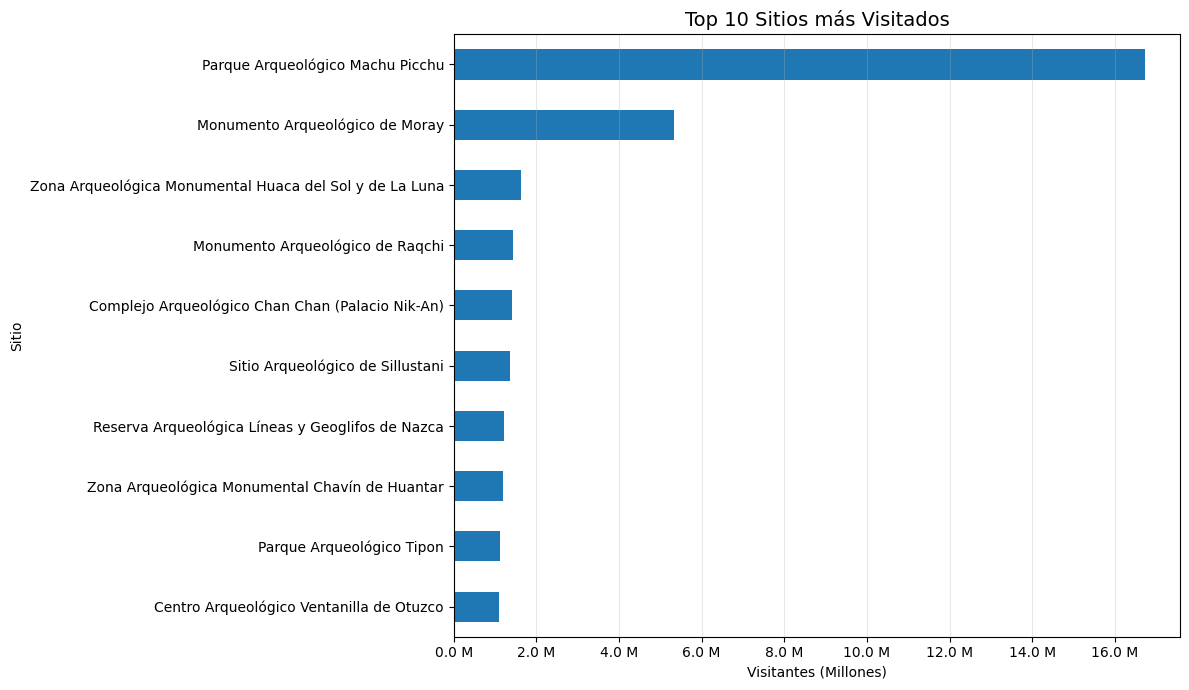

In [84]:
# 8. ANÁLISIS 3: TOP 10 SITIOS
top_sitios = (
    df.groupby('sitio')['total_visitantes']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,7))

top_sitios.sort_values().plot(kind='barh')

plt.title("Top 10 Sitios más Visitados", fontsize=14)
plt.xlabel("Visitantes (Millones)")
plt.ylabel("Sitio")

# Formato en millones
ax = plt.gca()

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f} M')
)

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

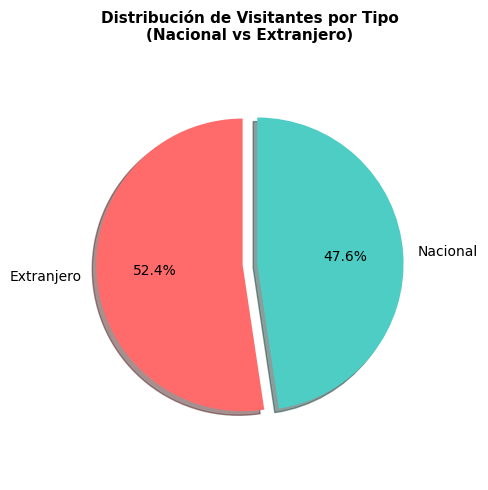

In [85]:
# 9. ANÁLISIS 4: TIPO DE VISITANTE
# (Agrupar por la columna 'tipo_visitante' y sumar los 'visitantes_pagantes')
tipo_visitantes = df.groupby('tipo_visitante')['total_visitantes'].sum()


# Crear el gráfico circular
plt.figure(figsize=(5,5))
plt.pie(tipo_visitantes.values,
        labels=tipo_visitantes.index,
        autopct='%1.1f%%',
        startangle=90,
        explode=(0.05, 0.05),  # Separar ligeramente las rebanadas
        shadow=True,
        colors=['#FF6B6B', '#4ECDC4'])  # Colores personalizados

plt.title("Distribución de Visitantes por Tipo\n(Nacional vs Extranjero)",
          fontsize=11,
          fontweight='bold')
plt.ylabel("")  # Eliminar la etiqueta del eje Y
plt.axis('equal')  # Asegurar que el gráfico sea circular
plt.tight_layout()
plt.show()


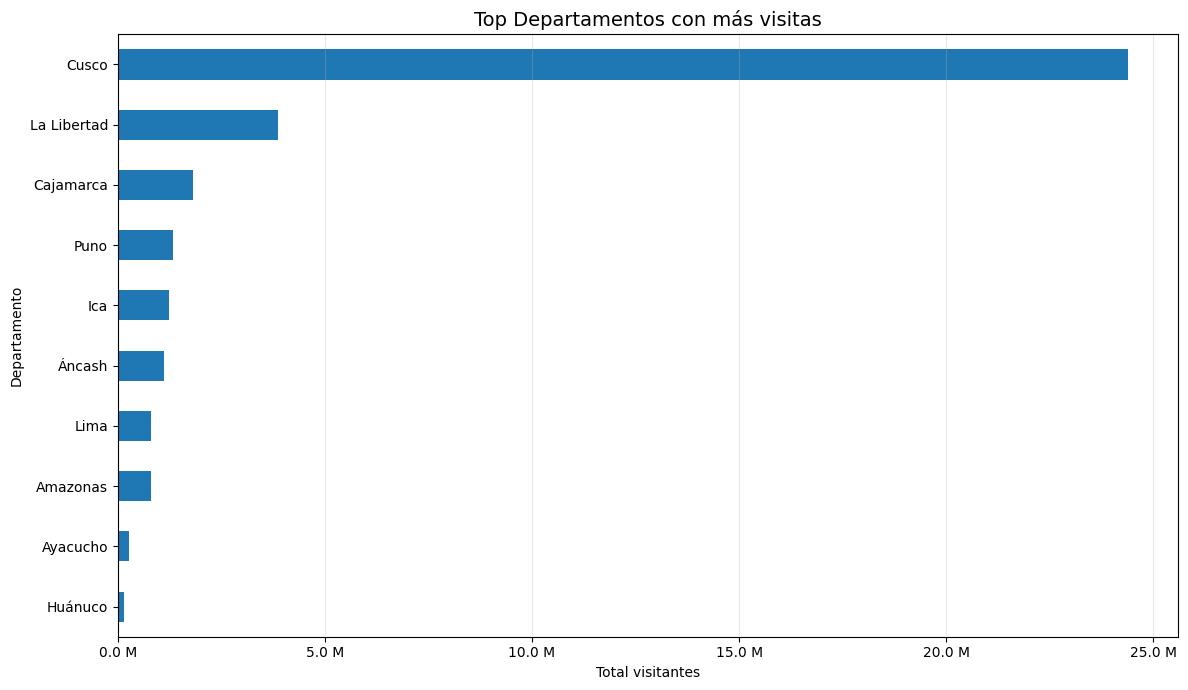


 TOP 10 DEPARTAMENTOS:
--------------------------------------------------
 1. Cusco          :   24,378,343 visitantes
 2. La Libertad    :    3,864,555 visitantes
 3. Cajamarca      :    1,811,783 visitantes
 4. Puno           :    1,339,604 visitantes
 5. Ica            :    1,227,573 visitantes
 6. Áncash         :    1,108,021 visitantes
 7. Lima           :      813,426 visitantes
 8. Amazonas       :      799,196 visitantes
 9. Ayacucho       :      278,784 visitantes
10. Huánuco        :      146,634 visitantes


In [86]:
# 10. ANÁLISIS 5: POR DEPARTAMENTO
dpto = df.groupby('departamento')['visitantes_pagantes'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,7))
dpto.sort_values().plot(kind='barh') #Ordenamos de menor a mayor usando barras horizontales

plt.title("Top Departamentos con más visitas", fontsize=14)
plt.xlabel("Total visitantes")
plt.ylabel("Departamento")

# Formato en millones
ax = plt.gca()

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f} M')
)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar también los números (opcional)
print("\n TOP 10 DEPARTAMENTOS:")
print("-" * 50)
for i, (depto, visitas) in enumerate(dpto.items(), 1):
    print(f"{i:2d}. {depto:15s}: {visitas:>12,.0f} visitantes")

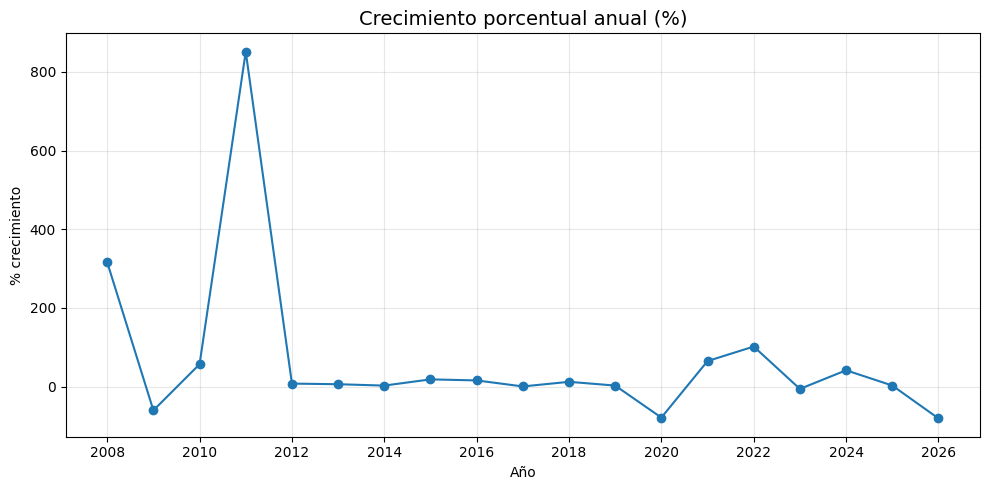

In [87]:
# 11. ANÁLISIS: CRECIMIENTO ANUAL

# Asegurar orden por año (IMPORTANTE)
visitas_anio = visitas_anio.sort_index()

# Calcular crecimiento %
crecimiento = visitas_anio.pct_change() * 100

plt.figure(figsize=(10,5))
crecimiento.plot(marker='o')

#Ponemos a enteros los años
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.title("Crecimiento porcentual anual (%)", fontsize=14)
plt.xlabel("Año")
plt.ylabel("% crecimiento")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [88]:
df[df['anio'] == 2010].shape

(122, 9)

In [89]:
df[df['anio'] == 2011].shape

(950, 9)

In [90]:
#Los primeros años presentan menor cantidad de registros disponibles,
#por lo que el incremento observado en 2011 podría estar influenciado
#por cambios en la cobertura de la base de datos.
visitas_anuales = df.groupby('anio')['total_visitantes'].sum().reset_index()

print(visitas_anuales)


    anio  total_visitantes
0   2007             77723
1   2008            323286
2   2009            127395
3   2010            199727
4   2011           1900292
5   2012           2042551
6   2013           2163089
7   2014           2215249
8   2015           2618790
9   2016           3026329
10  2017           3034266
11  2018           3398531
12  2019           3482794
13  2020            733189
14  2021           1208205
15  2022           2436720
16  2023           2290442
17  2024           3237356
18  2025           3321997
19  2026            632205


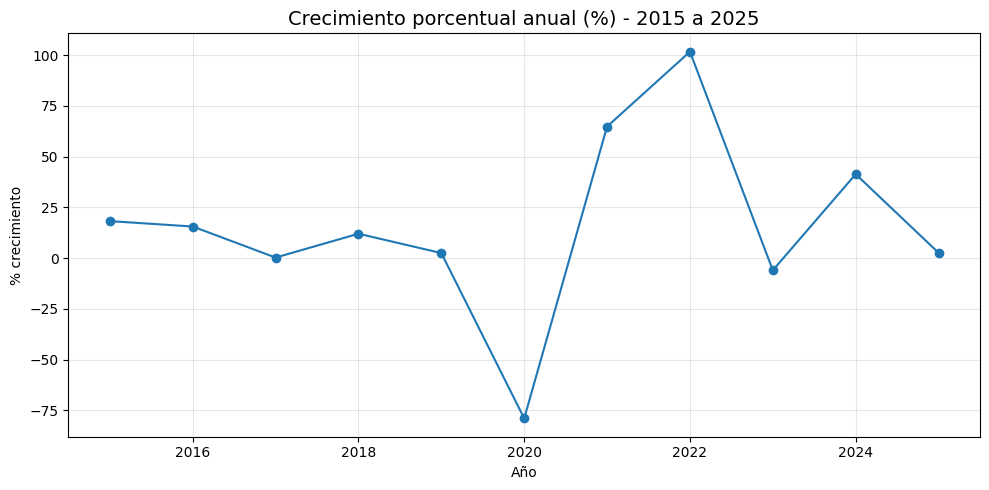

In [91]:
# 11. ANÁLISIS: CRECIMIENTO ANUAL DESDE EL 2015 - 2025
#PARA TENER UNA MEJOR OBSERVACIÓN DEL CRECIMIENTO ANUAL SE PRIOORIZÓ LOS AÑOS 2015 AL 2025, YA QUE EL 2026 aun tienem eses incompletos.

visitas_anio = visitas_anio.sort_index()

# Calcular crecimiento %
crecimiento = visitas_anio.pct_change() * 100

# Filtrar solo años desde 2015 hasta 2025
crecimiento_filtrado = crecimiento.loc[2015:2025]

plt.figure(figsize=(10,5))
crecimiento_filtrado.plot(marker='o')

plt.title("Crecimiento porcentual anual (%) - 2015 a 2025", fontsize=14)
plt.xlabel("Año")
plt.ylabel("% crecimiento")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

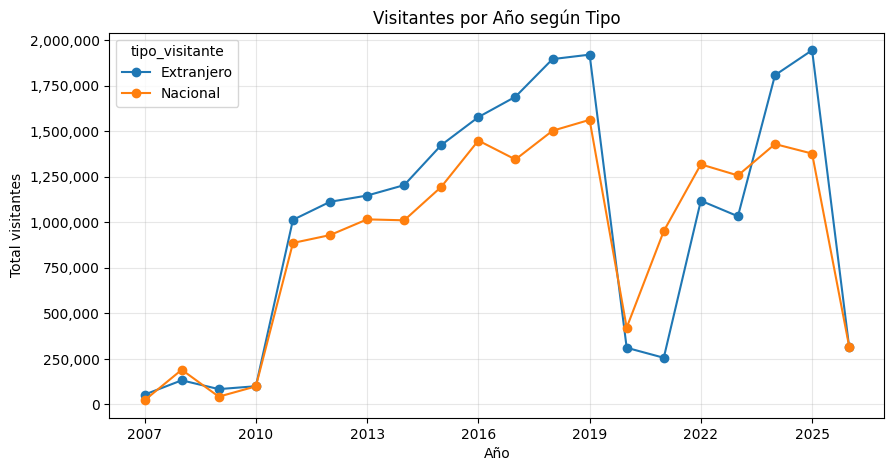

In [92]:
# 12. ANÁLISIS:Comparación de tipo de visitante en el tiempo
tipo_anio = df.groupby(['anio','tipo_visitante'])['total_visitantes'].sum().unstack()

tipo_anio.plot(figsize=(10,5), marker='o')

# para no mostrar con decimales
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title("Visitantes por Año según Tipo")
plt.xlabel("Año")
plt.ylabel("Total visitantes")
plt.grid(alpha=0.3)
plt.show()

                                                           antes  \
sitio                                                              
Parque Arqueológico Machu Picchu                    45679.766667   
Sitio Arqueológico Huaca Arco Iris (Huaca El Dr...   2282.337963   
Monumento Arqueológico de Raqchi                     4751.986111   
Zona Arqueológica Monumental Huaca del Sol y de...   5302.180556   
Parque Arqueológico Macchu Picchu (Ruta 1: Cami...   3181.856481   
Sitio Arqueológico de Sillustani                     3356.589744   
Sitio Arqueológico Caral                             2544.018519   
Complejo Arqueológico Chan Chan (Palacio Nik-An)     4233.240741   
Paisaje Cultural Arqueológico Cumbemayo              2347.828704   
Zona Arqueológica Monumental El Brujo                2127.533654   

                                                         despues        caida  
sitio                                                                          
Parque Arqueológico Mac

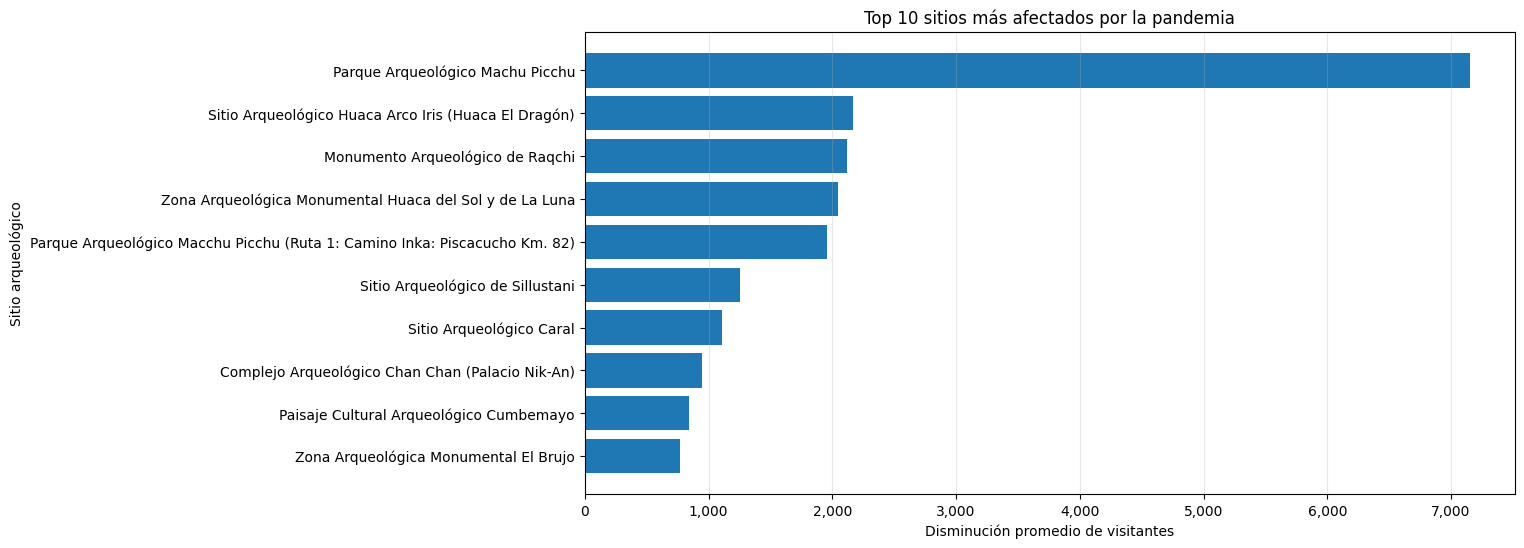

In [93]:
# ==========================================
# VISITAS ANTES DEL 2020
# ==========================================
antes = df[df['anio'] < 2020]

promedio_antes = (
    antes.groupby('sitio')['total_visitantes']
    .mean()
)

# ==========================================
# VISITAS DESDE 2020
# ==========================================
despues = df[df['anio'] >= 2020]

promedio_despues = (
    despues.groupby('sitio')['total_visitantes']
    .mean()
)

# ==========================================
# UNIR DATOS
# ==========================================
comparacion = pd.DataFrame({
    'antes': promedio_antes,
    'despues': promedio_despues
})

# ==========================================
# CALCULAR DIFERENCIA
# ==========================================
comparacion['caida'] = (
    comparacion['antes'] - comparacion['despues']
)

# ==========================================
# TOP 10 MÁS AFECTADOS
# ==========================================
top_afectados = comparacion.sort_values(
    by='caida',
    ascending=False
).head(10)

print(top_afectados)

# ==========================================
# GRÁFICO
# ==========================================
plt.figure(figsize=(12,6))

plt.barh(
    top_afectados.index,
    top_afectados['caida']
)

plt.title('Top 10 sitios más afectados por la pandemia')
plt.xlabel('Disminución promedio de visitantes')
plt.ylabel('Sitio arqueológico')

# Formato bonito
ax = plt.gca()

ax.xaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)

plt.gca().invert_yaxis()

plt.grid(axis='x', alpha=0.3)

plt.show()

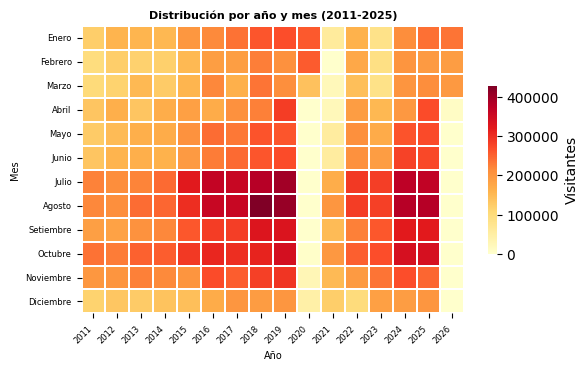

In [95]:
#13. ANALISIS:
df['mes'] = df['mes'].str.strip()

# Transponer datos para que los años estén en columnas y meses en filas
# Filtrar solo años desde 2011
import seaborn as sns

df['mes'] = pd.Categorical(df['mes'], categories=orden_meses, ordered=True)

#Sumar visitantes por cada combinación año–mes
heatmap_data = df.pivot_table(
    values='total_visitantes',
    index='anio',
    columns='mes',
    aggfunc='sum',
    observed=False
)

orden_meses = [
    'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
    'Julio', 'Agosto', 'Setiembre', 'Octubre', 'Noviembre', 'Diciembre'
]

heatmap_data_filtrado = heatmap_data.loc[2011:]


plt.figure(figsize=(6, 4))

sns.heatmap(
    heatmap_data_filtrado.T,  # .T transpone la matriz
    annot=False,
    cmap="YlOrRd",
    linewidths=0.2,
    linecolor='white',
    cbar_kws={'label': 'Visitantes', 'shrink': 0.5},
    square=True
)

plt.title("Distribución por año y mes (2011-2025)", fontsize=8, fontweight='bold')
plt.xlabel("Año", fontsize=7)
plt.ylabel("Mes", fontsize=7)
plt.xticks(rotation=45, ha='right', fontsize=6)
plt.yticks(fontsize=6)

plt.tight_layout()
plt.show()